In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

print("All libraries loaded successfully.")
print("Next step: upload your CSV. ")

All libraries loaded successfully.
Next step: upload your CSV. 


In [6]:
df = pd.read_csv('Data.csv')

print("=== DATASET OVERVIEW ===")
print(f"Total transactions : {len(df):,}")
print(f"Total fraud cases  : {df['isFraud'].sum():,}")
print(f"Overall fraud rate : {df['isFraud'].mean()*100:.4f}%")
print(f"System flagged     : {df['isFlaggedFraud'].sum():,}")
print(f"\nTransaction types:")
print(df['type'].value_counts())
print(f"\nFraud cases by type:")
print(df.groupby('type')['isFraud'].sum().sort_values(ascending=False))
print(f"\nTotal fraud exposure : ${df[df['isFraud']==1]['amount'].sum():,.0f}")


=== DATASET OVERVIEW ===
Total transactions : 6,362,620
Total fraud cases  : 8,213
Overall fraud rate : 0.1291%
System flagged     : 16

Transaction types:
type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

Fraud cases by type:
type
CASH_OUT    4116
TRANSFER    4097
CASH_IN        0
DEBIT          0
PAYMENT        0
Name: isFraud, dtype: int64

Total fraud exposure : $12,056,415,428


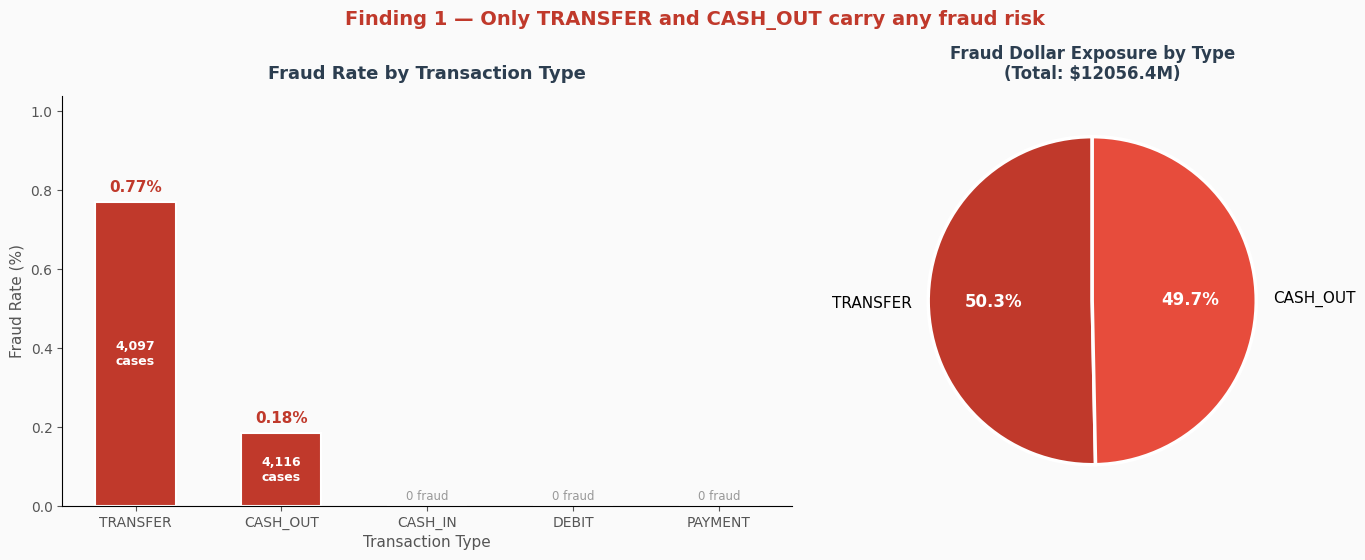

    type   total  fraud  fraud_rate_pct
TRANSFER  532909   4097           0.769
CASH_OUT 2237500   4116           0.184
 CASH_IN 1399284      0           0.000
   DEBIT   41432      0           0.000
 PAYMENT 2151495      0           0.000


In [7]:
# Finding 1: Only TRANSFER and CASH_OUT carry fraud risk

# Calculate fraud stats by type
fraud_by_type = df.groupby('type').agg(
    total=('isFraud', 'count'),
    fraud=('isFraud', 'sum')
).reset_index()
fraud_by_type['fraud_rate_pct'] = (
    fraud_by_type['fraud'] / fraud_by_type['total'] * 100).round(3)
fraud_by_type['fraud_exposure'] = (
    df[df['isFraud']==1]
    .groupby('type')['amount'].sum()
    .reindex(fraud_by_type['type'])
    .fillna(0)
    .values
)
fraud_by_type = fraud_by_type.sort_values('fraud_rate_pct', ascending=False)

# Build the figure — two panels side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                          gridspec_kw={'width_ratios': [1.6, 1]})
fig.patch.set_facecolor('#FAFAFA')

# ── Left panel: bar chart ──
ax = axes[0]
ax.set_facecolor('#FAFAFA')
colors = ['#C0392B' if r > 0 else '#C8C8C8'
          for r in fraud_by_type['fraud_rate_pct']]
bars = ax.bar(fraud_by_type['type'], fraud_by_type['fraud_rate_pct'],
              color=colors, width=0.55, edgecolor='white', linewidth=1.5)

for bar, row in zip(bars, fraud_by_type.itertuples()):
    if row.fraud_rate_pct > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                row.fraud_rate_pct + 0.02,
                f'{row.fraud_rate_pct:.2f}%',
                ha='center', va='bottom',
                fontsize=11, fontweight='bold', color='#C0392B')
        ax.text(bar.get_x() + bar.get_width()/2,
                row.fraud_rate_pct / 2,
                f'{int(row.fraud):,}\ncases',
                ha='center', va='center',
                fontsize=9, color='white', fontweight='bold')
    else:
        ax.text(bar.get_x() + bar.get_width()/2,
                0.008, '0 fraud',
                ha='center', va='bottom', fontsize=8.5, color='#999')

ax.set_title('Fraud Rate by Transaction Type',
             fontsize=13, fontweight='bold', pad=12, color='#2C3E50')
ax.set_xlabel('Transaction Type', fontsize=11, color='#555')
ax.set_ylabel('Fraud Rate (%)', fontsize=11, color='#555')
ax.set_ylim(0, fraud_by_type['fraud_rate_pct'].max() * 1.35)
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(colors='#555')

# ── Right panel: pie chart showing dollar exposure ──
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')
fraud_exposure_data = fraud_by_type[fraud_by_type['fraud_exposure'] > 0]
total_exp = fraud_exposure_data['fraud_exposure'].sum()
wedges, texts, autotexts = ax2.pie(
    fraud_exposure_data['fraud_exposure'],
    labels=fraud_exposure_data['type'],
    autopct='%1.1f%%',
    colors=['#C0392B', '#E74C3C'],
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2.5),
    textprops={'fontsize': 11}
)
for at in autotexts:
    at.set_fontweight('bold')
    at.set_color('white')
    at.set_fontsize(12)
ax2.set_title(f'Fraud Dollar Exposure by Type\n(Total: ${total_exp/1e6:.1f}M)',
              fontsize=12, fontweight='bold', pad=12, color='#2C3E50')

plt.suptitle('Finding 1 — Only TRANSFER and CASH_OUT carry any fraud risk',
             fontsize=14, fontweight='bold', color='#C0392B', y=1.01)
plt.tight_layout()
plt.savefig('chart1_fraud_by_type.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

print(fraud_by_type[['type','total','fraud','fraud_rate_pct']].to_string(index=False))

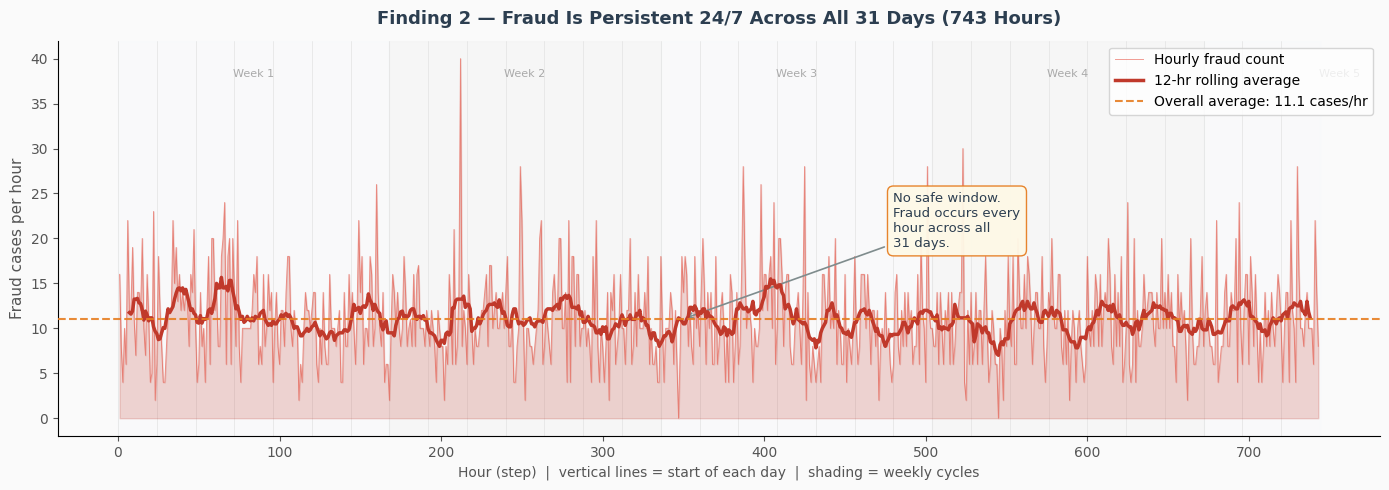

Peak hour   : 212  (40 cases)
Lowest hour : 347  (0 cases)
Avg/hr      : 11.05


In [8]:
# Finding 2: Fraud is persistent 24/7 — no safe window

hourly = df.groupby('step')['isFraud'].sum().reset_index()
hourly.columns = ['hour', 'fraud_count']
rolling_avg = hourly['fraud_count'].rolling(12, center=True).mean()
overall_avg = hourly['fraud_count'].mean()

fig, ax = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Shade by week so the viewer can see weekly cycles
week_colors = ['#F8F9FA', '#F0F0F0']
for w in range(5):
    start = w * 168
    end   = min(start + 168, 744)
    ax.axvspan(start, end, alpha=0.3, color=week_colors[w % 2], zorder=0)
    if start < 740:
        ax.text(start + 84, hourly['fraud_count'].max() * 0.97,
                f'Week {w+1}', ha='center', fontsize=8,
                color='#AAA', va='top')

# Daily grid lines
for d in range(0, 744, 24):
    ax.axvline(d, color='#DDD', linewidth=0.4, zorder=1)

ax.fill_between(hourly['hour'], hourly['fraud_count'],
                alpha=0.2, color='#C0392B', zorder=2)
ax.plot(hourly['hour'], hourly['fraud_count'],
        color='#E74C3C', linewidth=0.7, alpha=0.55,
        label='Hourly fraud count', zorder=3)
ax.plot(hourly['hour'], rolling_avg,
        color='#C0392B', linewidth=2.5,
        label='12-hr rolling average', zorder=4)
ax.axhline(overall_avg, color='#E67E22', linewidth=1.5,
           linestyle='--', alpha=0.9,
           label=f'Overall average: {overall_avg:.1f} cases/hr', zorder=5)

ax.annotate(
    f'No safe window.\nFraud occurs every\nhour across all\n31 days.',
    xy=(350, overall_avg),
    xytext=(480, overall_avg + 8),
    fontsize=9.5, color='#2C3E50',
    arrowprops=dict(arrowstyle='->', color='#7F8C8D', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#FEF9E7',
              edgecolor='#E67E22', alpha=0.95)
)

ax.set_title('Finding 2 — Fraud Is Persistent 24/7 Across All 31 Days (743 Hours)',
             fontsize=13, fontweight='bold', color='#2C3E50', pad=12)
ax.set_xlabel('Hour (step)  |  vertical lines = start of each day  |'
              '  shading = weekly cycles',
              fontsize=10, color='#555')
ax.set_ylabel('Fraud cases per hour', fontsize=11, color='#555')
ax.legend(fontsize=10, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.tick_params(colors='#555')

plt.tight_layout()
plt.savefig('chart2_fraud_over_time.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

print(f"Peak hour   : {hourly.loc[hourly['fraud_count'].idxmax(), 'hour']}"
      f"  ({hourly['fraud_count'].max()} cases)")
print(f"Lowest hour : {hourly.loc[hourly['fraud_count'].idxmin(), 'hour']}"
      f"  ({hourly['fraud_count'].min()} cases)")
print(f"Avg/hr      : {overall_avg:.2f}")

Fraud at the $1M limit : 2,706  (32.9%)


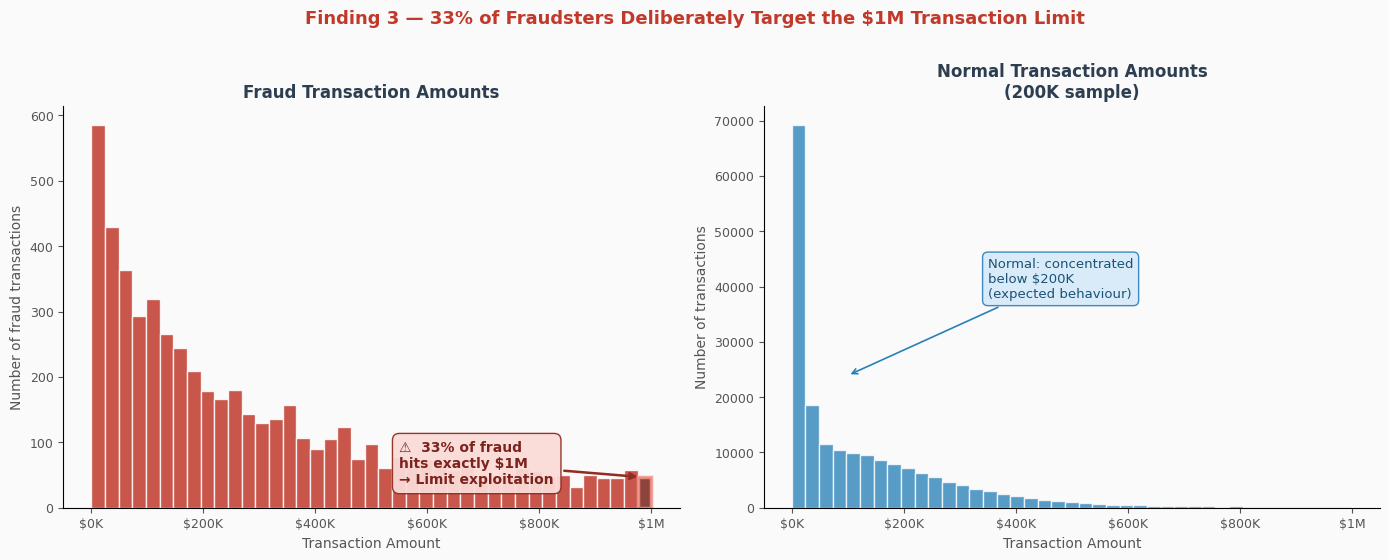

In [9]:
# Finding 3: Fraudsters deliberately target the $1M limit

fraud_df  = df[df['isFraud'] == 1].copy()
normal_df = df[df['isFraud'] == 0].copy()

# Key statistic
limit_fraud = (fraud_df['amount'] >= 999999).sum()
limit_pct   = limit_fraud / len(fraud_df) * 100
print(f"Fraud at the $1M limit : {limit_fraud:,}  ({limit_pct:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.patch.set_facecolor('#FAFAFA')
bins = np.linspace(0, 1_000_000, 42)

# ── Left: fraud amounts ──
ax1 = axes[0]
ax1.set_facecolor('#FAFAFA')
n, b, patches = ax1.hist(fraud_df['amount'], bins=bins,
                          color='#C0392B', alpha=0.85, edgecolor='white')
# Make the final bar (the $1M spike) darker to draw the eye
patches[-1].set_facecolor('#7B241C')
patches[-1].set_edgecolor('#F1948A')
patches[-1].set_linewidth(2.5)

ax1.annotate(
    f'⚠  {limit_pct:.0f}% of fraud\nhits exactly $1M\n→ Limit exploitation',
    xy=(980000, n[-1]),
    xytext=(550000, n[-1] * 0.78),
    fontsize=10, fontweight='bold', color='#7B241C',
    arrowprops=dict(arrowstyle='->', color='#922B21', lw=1.8),
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FADBD8',
              edgecolor='#922B21', alpha=0.95)
)
ax1.set_title('Fraud Transaction Amounts',
              fontsize=12, fontweight='bold', color='#2C3E50')
ax1.set_xlabel('Transaction Amount', fontsize=10, color='#555')
ax1.set_ylabel('Number of fraud transactions', fontsize=10, color='#555')
ax1.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _:
        '$1M' if x >= 999999 else f'${int(x/1000)}K'))
ax1.spines[['top', 'right']].set_visible(False)
ax1.tick_params(colors='#555', labelsize=9)

# ── Right: normal amounts (sample for speed) ──
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')
normal_sample = normal_df['amount'].sample(
    min(200000, len(normal_df)), random_state=42)
n2, b2, patches2 = ax2.hist(normal_sample, bins=bins,
                              color='#2980B9', alpha=0.78, edgecolor='white')
ax2.annotate(
    'Normal: concentrated\nbelow $200K\n(expected behaviour)',
    xy=(100000, n2[:5].mean()),
    xytext=(350000, n2.max() * 0.55),
    fontsize=9.5, color='#1A5276',
    arrowprops=dict(arrowstyle='->', color='#2980B9', lw=1.2),
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#D6EAF8',
              edgecolor='#2980B9', alpha=0.9)
)
ax2.set_title('Normal Transaction Amounts\n(200K sample)',
              fontsize=12, fontweight='bold', color='#2C3E50')
ax2.set_xlabel('Transaction Amount', fontsize=10, color='#555')
ax2.set_ylabel('Number of transactions', fontsize=10, color='#555')
ax2.xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _:
        '$1M' if x >= 999999 else f'${int(x/1000)}K'))
ax2.spines[['top', 'right']].set_visible(False)
ax2.tick_params(colors='#555', labelsize=9)

plt.suptitle(
    f'Finding 3 — {limit_pct:.0f}% of Fraudsters Deliberately'
    ' Target the $1M Transaction Limit',
    fontsize=13, fontweight='bold', color='#C0392B', y=1.01)
plt.tight_layout()
plt.savefig('chart3_amount_distribution.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


Chart 4 values from your real data:
    type  fraud_cases  avg_per_case_K  total_exposure_M
CASH_OUT         4116          1455.0            5989.2
TRANSFER         4097          1481.0            6067.2


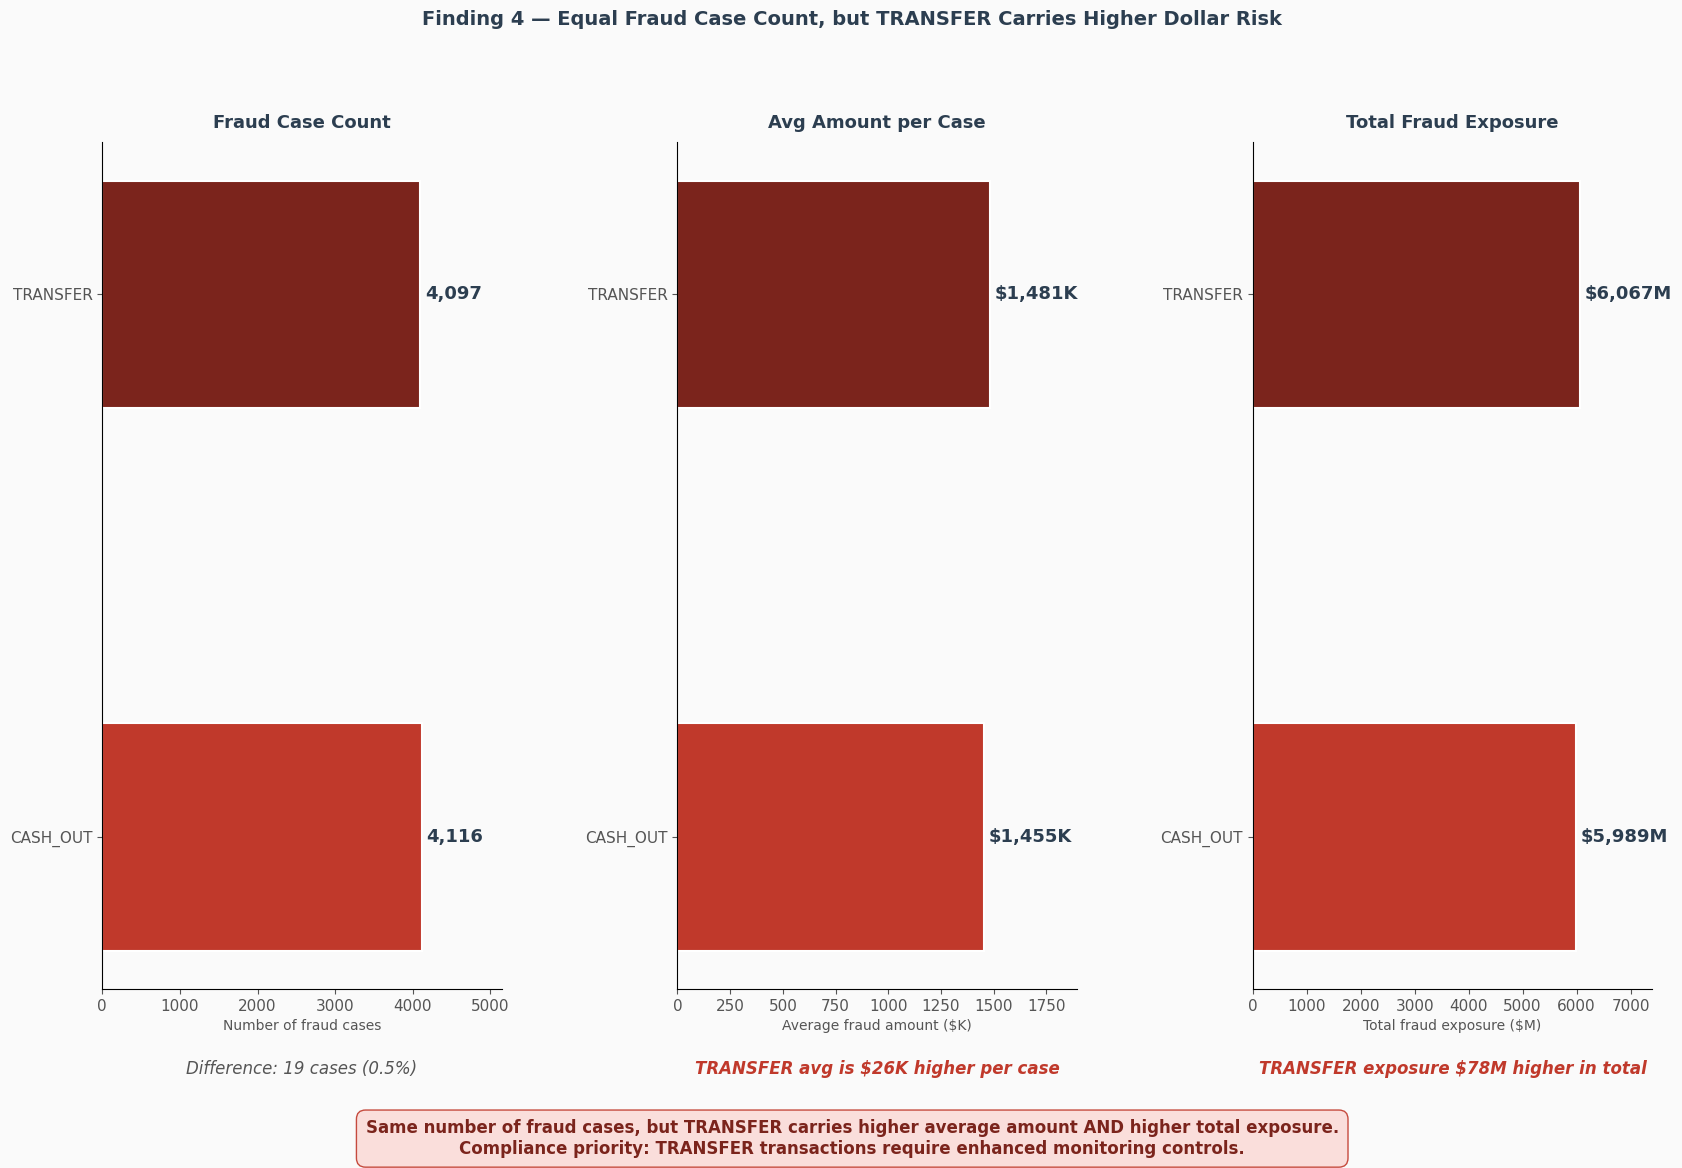

In [34]:
from IPython.utils import text
from os import WSTOPPED
# Finding 4: TRANSFER carries higher dollar exposure than
# CASH_OUT despite identical fraud case counts

type_stats = df[df['isFraud']==1].groupby('type').agg(
    fraud_cases=('isFraud', 'count'),
    total_exposure=('amount', 'sum'),
    avg_per_case=('amount', 'mean')
).reset_index()
type_stats['total_exposure_M'] = (type_stats['total_exposure'] / 1e6).round(1)
type_stats['avg_per_case_K']   = (type_stats['avg_per_case'] / 1e3).round(0)

print("\nChart 4 values from your real data:")
print(type_stats[['type','fraud_cases','avg_per_case_K',
                   'total_exposure_M']].to_string(index=False))

categories = type_stats['type'].tolist()
cases_v    = type_stats['fraud_cases'].tolist()
avg_v      = type_stats['avg_per_case_K'].tolist()
exp_v      = type_stats['total_exposure_M'].tolist()
bar_clrs   = ['#C0392B', '#7B241C']

fig = plt.figure(figsize=(20, 11))
fig.patch.set_facecolor('#FAFAFA')
gs = gridspec.GridSpec(1, 3, figure=fig, wspace=0.44)

# Panel 1: Fraud case count
ax1 = fig.add_subplot(gs[0]); ax1.set_facecolor('#FAFAFA')
b1 = ax1.barh(categories, cases_v, color=bar_clrs,
              edgecolor='white', linewidth=1.5, height=0.42)
for bar, val in zip(b1, cases_v):
    ax1.text(val + max(cases_v)*0.015,
            bar.get_y()+bar.get_height()/2,
            f'{val:,}', va='center', fontsize=13,
            fontweight='bold', color='#2C3E50')
ax1.set_xlim(0, max(cases_v)*1.25)
ax1.set_title('Fraud Case Count', fontsize=13,
              fontweight='bold', color='#2C3E50', pad=10)
ax1.set_xlabel('Number of fraud cases', fontsize=10, color='#555')
ax1.spines[['top','right']].set_visible(False)
ax1.tick_params(colors='#555', labelsize=11)
diff_c = abs(cases_v[0] - cases_v[1])
ax1.text(0.5, -0.10,
        f'Difference: {diff_c} cases ({diff_c/min(cases_v)*100:.1f}%)',
        transform=ax1.transAxes, ha='center', fontsize=12,
        color='#555', style='italic')

# Panel 2: Average amount per case
ax2 = fig.add_subplot(gs[1]); ax2.set_facecolor('#FAFAFA')
b2 = ax2.barh(categories, avg_v, color=bar_clrs,
              edgecolor='white', linewidth=1.5, height=0.42)
for bar, val in zip(b2, avg_v):
    ax2.text(val + max(avg_v)*0.015,
            bar.get_y()+bar.get_height()/2,
            f'${val:,.0f}K', va='center', fontsize=13,
            fontweight='bold', color='#2C3E50')
ax2.set_xlim(0, max(avg_v)*1.28)
ax2.set_title('Avg Amount per Case', fontsize=13,
              fontweight='bold', color='#2C3E50', pad=10)
ax2.set_xlabel('Average fraud amount ($K)', fontsize=10, color='#555')
ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(colors='#555', labelsize=11)
higher_avg = categories[avg_v.index(max(avg_v))]
diff_a = abs(avg_v[0] - avg_v[1])
ax2.text(0.5, -0.10,
        f'{higher_avg} avg is ${diff_a:.0f}K higher per case',
        transform=ax2.transAxes, ha='center', fontsize=12,
        color='#C0392B', fontweight='bold', style='italic')

# Panel 3: Total exposure
ax3 = fig.add_subplot(gs[2]); ax3.set_facecolor('#FAFAFA')
b3 = ax3.barh(categories, exp_v, color=bar_clrs,
              edgecolor='white', linewidth=1.5, height=0.42)
for bar, val in zip(b3, exp_v):
    ax3.text(val + max(exp_v)*0.015,
            bar.get_y()+bar.get_height()/2,
            f'${val:,.0f}M', va='center', fontsize=13,
            fontweight='bold', color='#2C3E50')
ax3.set_xlim(0, max(exp_v)*1.22)
ax3.set_title('Total Fraud Exposure', fontsize=13,
              fontweight='bold', color='#2C3E50', pad=10)
ax3.set_xlabel('Total fraud exposure ($M)', fontsize=10, color='#555')
ax3.spines[['top','right']].set_visible(False)
ax3.tick_params(colors='#555', labelsize=11)
higher_exp = categories[exp_v.index(max(exp_v))]
diff_e = abs(exp_v[0] - exp_v[1])
ax3.text(0.5, -0.10,
        f'{higher_exp} exposure ${diff_e:.0f}M higher in total',
        transform=ax3.transAxes, ha='center', fontsize=12,
        color='#C0392B', fontweight='bold', style='italic')

# Key insight box below all 3 panels
fig.text(0.5, -0.04,
    'Same number of fraud cases, but TRANSFER carries higher average amount'
    ' AND higher total exposure.\n'
    'Compliance priority: TRANSFER transactions require enhanced monitoring controls.',
    ha='center', fontsize=12, color='#7B241C', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.55', facecolor='#FADBD8',
              edgecolor='#C0392B', alpha=0.9))
plt.suptitle(
    'Finding 4 — Equal Fraud Case Count,'
    ' but TRANSFER Carries Higher Dollar Risk',
    fontsize=14, fontweight='bold', color='#2C3E50', y=1)
plt.savefig('chart4_exposure_vs_volume.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


Chart 5 values:
  Total fraud : 8,213
  Flagged     : 16  (0.2%)
  Missed      : 8,197  (99.8%)


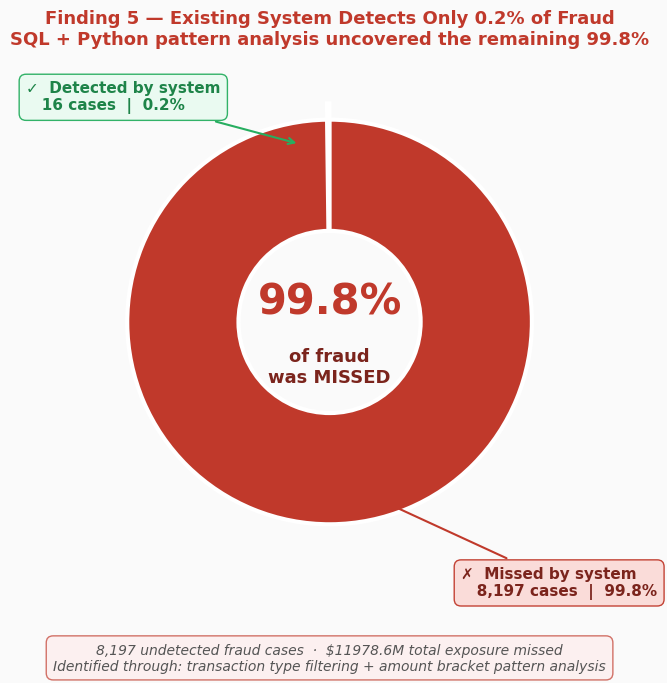

In [36]:
#Finding 5: Existing detection system misses 99.8% of fraud

total_fraud_n   = int(df['isFraud'].sum())
flagged_n       = int(
    df[(df['isFraud']==1) & (df['isFlaggedFraud']==1)]['isFraud'].sum())
missed_n        = total_fraud_n - flagged_n
missed_pct      = missed_n / total_fraud_n * 100
missed_exposure = df[(df['isFraud']==1) &
                     (df['isFlaggedFraud']==0)]['amount'].sum()

print(f"\nChart 5 values:")
print(f"  Total fraud : {total_fraud_n:,}")
print(f"  Flagged     : {flagged_n:,}  ({flagged_n/total_fraud_n*100:.1f}%)")
print(f"  Missed      : {missed_n:,}  ({missed_pct:.1f}%)")

fig, ax = plt.subplots(figsize=(10, 7))
fig.patch.set_facecolor('#FAFAFA')
ax.set_facecolor('#FAFAFA')

# Donut chart — wider ring makes the thin 0.2% slice visible
wedges, texts = ax.pie(
    [flagged_n, missed_n],
    colors=['#27AE60', '#C0392B'],
    startangle=90,
    wedgeprops=dict(width=0.55, edgecolor='white', linewidth=3),
    explode=(0.08, 0)
)

# Large number in the donut centre
ax.text(0, 0.10, f'{missed_pct:.1f}%', ha='center', va='center',
        fontsize=30, fontweight='bold', color='#C0392B')
ax.text(0, -0.22, 'of fraud\nwas MISSED', ha='center', va='center',
        fontsize=13, color='#7B241C', fontweight='bold')

# Callout annotation — green (detected) slice
ax.annotate(
    f'✓  Detected by system\n'
    f'   {flagged_n} cases  |  {flagged_n/total_fraud_n*100:.1f}%',
    xy=(-0.15, 0.88), xytext=(-1.5, 1.05),
    fontsize=11, fontweight='bold', color='#1E8449',
    arrowprops=dict(arrowstyle='->', color='#27AE60', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#EAFAF1',
              edgecolor='#27AE60', alpha=0.95))

# Callout annotation — red (missed) slice
ax.annotate(
    f'✗  Missed by system\n'
    f'   {missed_n:,} cases  |  {missed_pct:.1f}%',
    xy=(0.25, -0.88), xytext=(0.65, -1.35),
    fontsize=11, fontweight='bold', color='#7B241C',
    arrowprops=dict(arrowstyle='->', color='#C0392B', lw=1.5),
    bbox=dict(boxstyle='round,pad=0.45', facecolor='#FADBD8',
              edgecolor='#C0392B', alpha=0.95))

ax.set_title(
    f'Finding 5 — Existing System Detects Only'
    f' {flagged_n/total_fraud_n*100:.1f}% of Fraud\n'
    'SQL + Python pattern analysis uncovered the remaining 99.8%',
    fontsize=13, fontweight='bold', color='#C0392B', pad=18)

ax.text(0, -1.72,
    f'{missed_n:,} undetected fraud cases  ·'
    f'  ${missed_exposure/1e6:.1f}M total exposure missed\n'
    'Identified through: transaction type filtering'
    ' + amount bracket pattern analysis',
    ha='center', fontsize=10, color='#555', style='italic',
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#FDEDEC',
              edgecolor='#C0392B', alpha=0.7))
plt.tight_layout()
plt.savefig('chart5_detection_gap.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


Chart 6 — destination account breakdown:
  Targeted once : 8,125
  Targeted 2–5× : 44
  Targeted 6+×  : 0


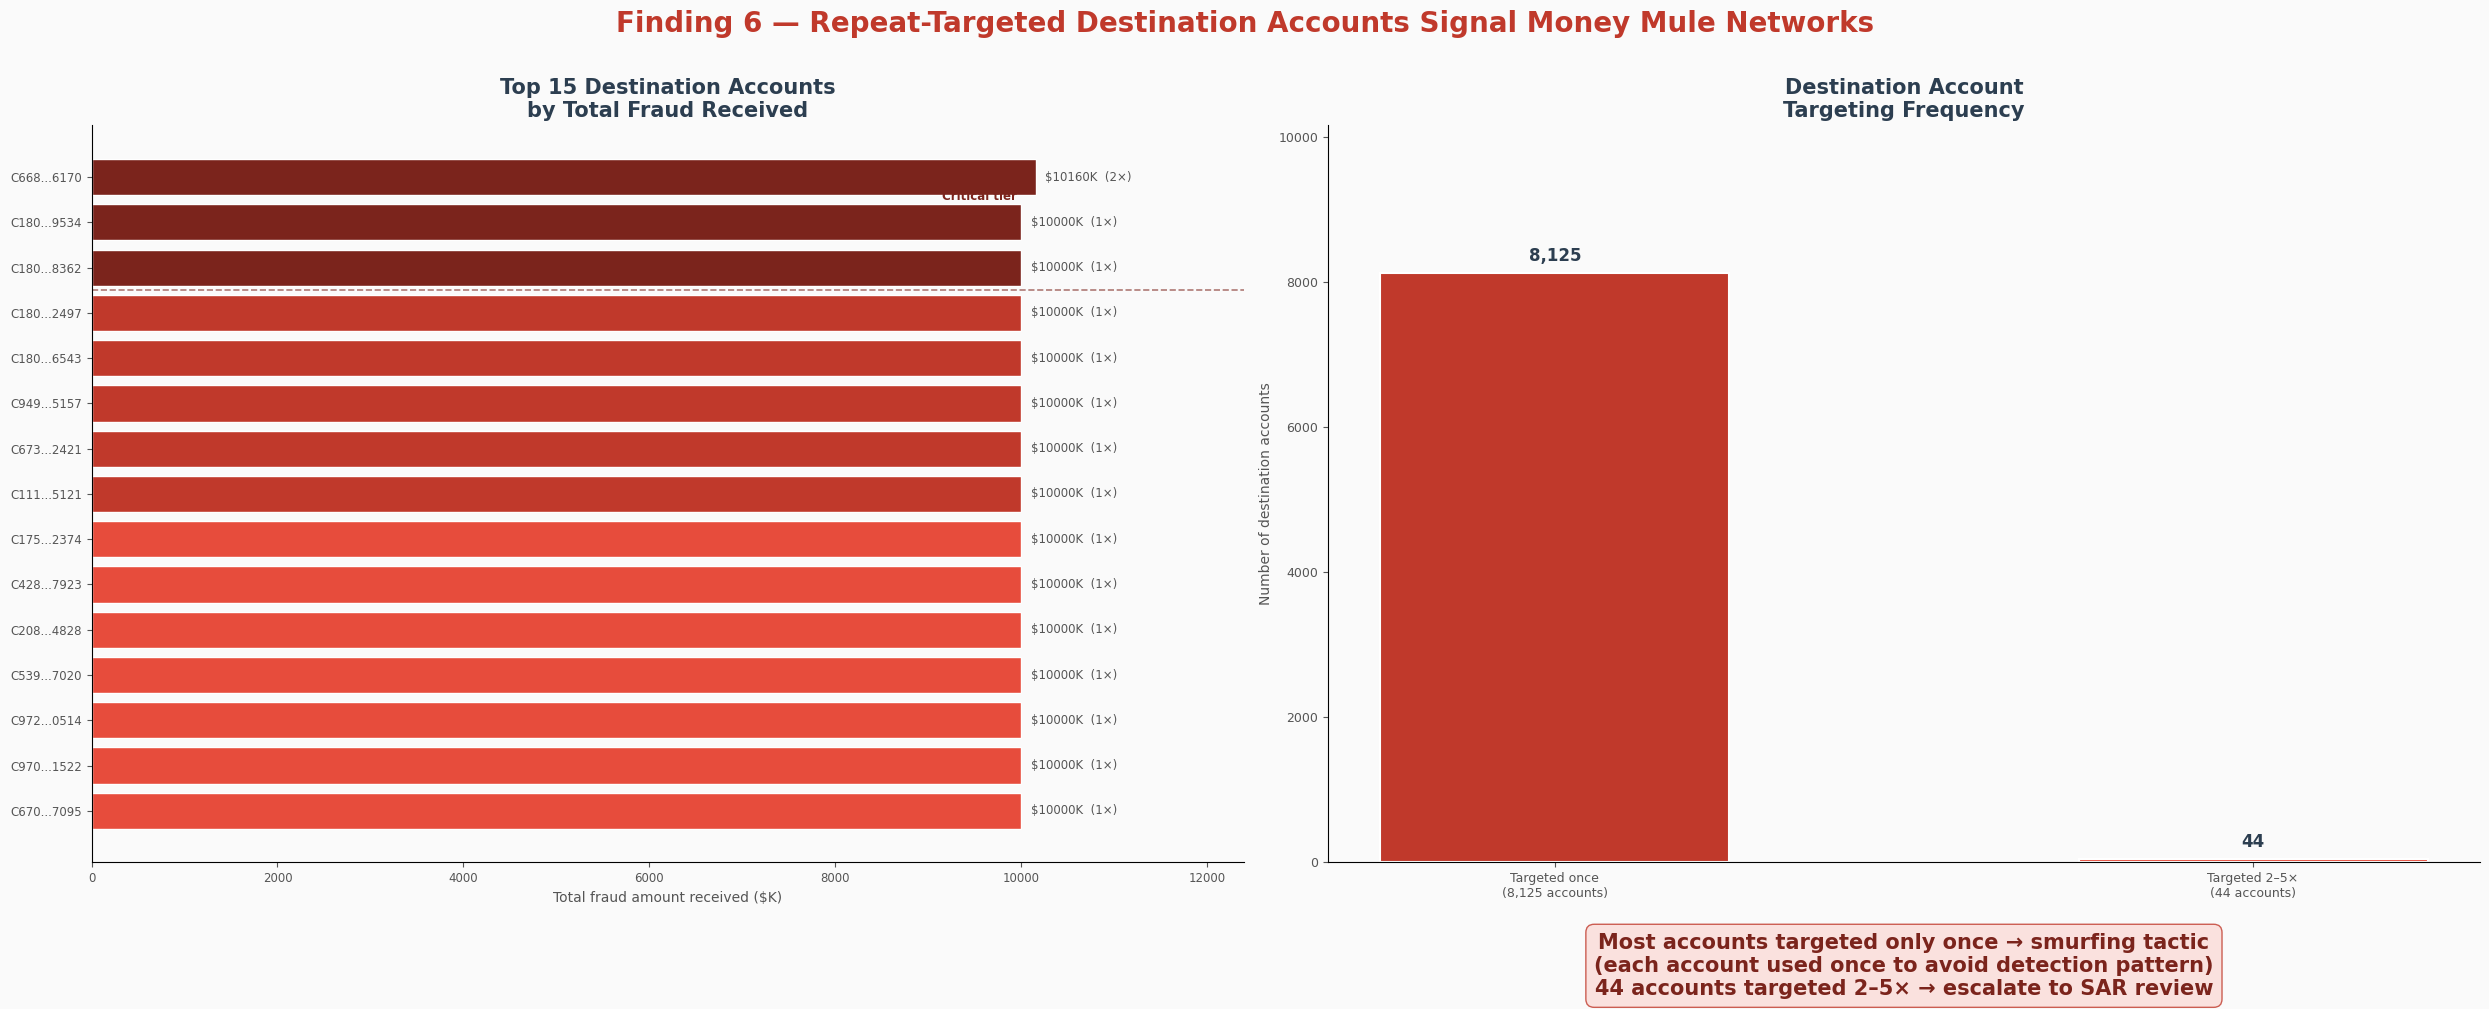

In [52]:
# Finding 6: Repeat-targeted destination accounts signal

fraud_df = df[df['isFraud']==1].copy()

top_dest = (
    fraud_df.groupby('nameDest')
            .agg(times_targeted=('isFraud','count'),
                 total_received=('amount','sum'))
            .sort_values('total_received', ascending=False)
            .head(15).reset_index()
)
top_dest['total_received_K'] = (top_dest['total_received']/1e3).round(1)
top_dest['label'] = (top_dest['nameDest'].str[:4] + '...'
                     + top_dest['nameDest'].str[-4:])

dest_counts   = fraud_df['nameDest'].value_counts()
single_dest   = (dest_counts == 1).sum()
repeat_2_5    = ((dest_counts >= 2) & (dest_counts <= 5)).sum()
repeat_6plus  = (dest_counts > 5).sum()

print(f"\nChart 6 — destination account breakdown:")
print(f"  Targeted once : {single_dest:,}")
print(f"  Targeted 2–5× : {repeat_2_5:,}")
print(f"  Targeted 6+×  : {repeat_6plus:,}")

fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.patch.set_facecolor('#FAFAFA')

# Left panel: top 15 accounts
ax1 = axes[0]; ax1.set_facecolor('#FAFAFA')
colors_b = ['#7B241C' if i < 3 else '#C0392B' if i < 8 else '#E74C3C'
            for i in range(len(top_dest))]
bars = ax1.barh(top_dest['label'][::-1],
                top_dest['total_received_K'][::-1],
                color=colors_b[::-1], edgecolor='white', linewidth=1)
for bar, val, cnt in zip(bars,
                          top_dest['total_received_K'][::-1],
                          top_dest['times_targeted'][::-1]):
    ax1.text(val + top_dest['total_received_K'].max()*0.01,
             bar.get_y()+bar.get_height()/2,
             f'${val:.0f}K  ({cnt}×)', va='center', fontsize=8.5, color='#555')
ax1.axhline(len(top_dest)-3-0.5,
            color='#7B241C', linestyle='--', linewidth=1.2, alpha=0.6)
ax1.text(top_dest['total_received_K'].max()*0.98, len(top_dest)-1.5,
         'Critical tier', ha='right', fontsize=8.5,
         color='#7B241C', fontweight='bold')
ax1.set_title('Top 15 Destination Accounts\nby Total Fraud Received',
              fontsize=15, fontweight='bold', color='#2C3E50')
ax1.set_xlabel('Total fraud amount received ($K)', fontsize=10, color='#555')
ax1.set_xlim(0, top_dest['total_received_K'].max()*1.22)
ax1.spines[['top','right']].set_visible(False)
ax1.tick_params(colors='#555', labelsize=8.5)

# Right panel:
ax2 = axes[1]; ax2.set_facecolor('#FAFAFA')

# Build bars dynamically — only include 6+ if it has data
bar_labels = [f'Targeted once\n({single_dest:,} accounts)',
              f'Targeted 2–5×\n({repeat_2_5} accounts)']
bar_values = [single_dest, repeat_2_5]
bar_colors = ['#C0392B', '#E74C3C']

if repeat_6plus > 0:
    bar_labels.append(f'Targeted 6+×\n({repeat_6plus} accounts)')
    bar_values.append(repeat_6plus)
    bar_colors.append('#7B241C')

bars2 = ax2.bar(bar_labels, bar_values, color=bar_colors,
                edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars2, bar_values):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height() + max(bar_values)*0.02,
             f'{val:,}', ha='center', fontsize=12,
             fontweight='bold', color='#2C3E50')

ax2.set_title('Destination Account\nTargeting Frequency',
              fontsize=15, fontweight='bold', color='#2C3E50')
ax2.set_ylabel('Number of destination accounts', fontsize=10, color='#555')
ax2.set_ylim(0, max(bar_values)*1.25)
ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(colors='#555', labelsize=9)

insight_txt = (
    f'Most accounts targeted only once → smurfing tactic\n'
    f'(each account used once to avoid detection pattern)\n'
    f'{repeat_2_5} accounts targeted 2–5× → escalate to SAR review'
)
ax2.text(0.5, -0.18, insight_txt,
         transform=ax2.transAxes, ha='center', fontsize=15,
         color='#7B241C', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FADBD8',
                   edgecolor='#C0392B', alpha=0.8))

plt.suptitle(
    'Finding 6 — Repeat-Targeted Destination Accounts Signal Money Mule Networks',
    fontsize=20, fontweight='bold', color='#C0392B', y=1.01)
plt.tight_layout()
plt.savefig('chart6_top_accounts.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()


Chart 7 — risk tier summary:
                         risk_tier  case_count  pct  avg_K  total_M
  Tier 1 — Critical (Score 75–100)        1056 35.2  139.0    147.1
Tier 2 — Investigate (Score 50–74)        1434 47.8 1720.0   2467.1
     Tier 3 — Monitor (Score 0–49)         510 17.0 3934.0   2006.1


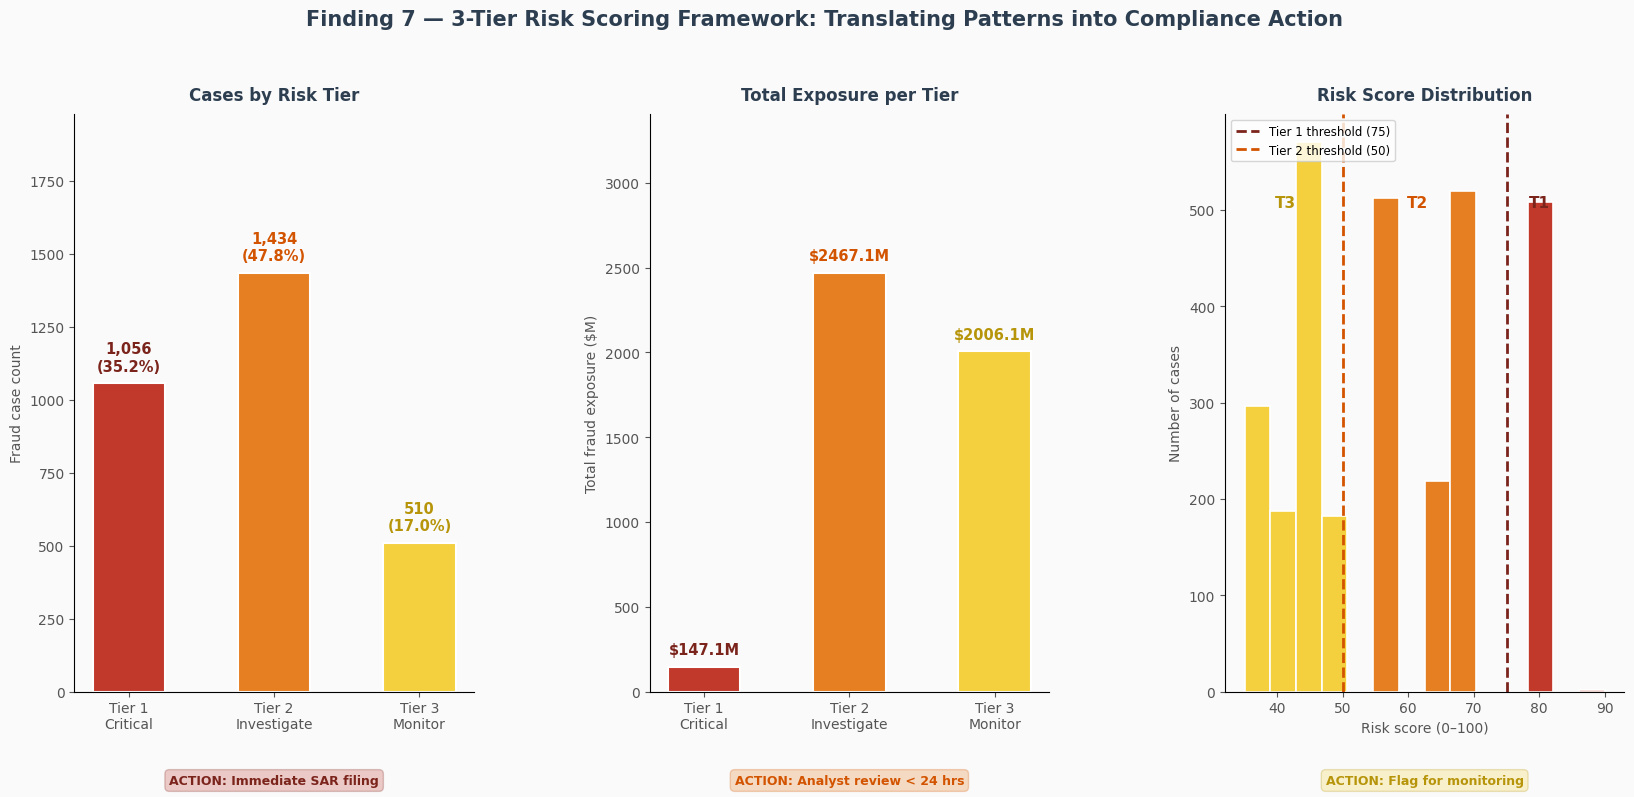

In [58]:
# Finding 7: 3-Tier Risk Scoring Framework

fraud_df2 = df[df['isFraud']==1].copy()
dest_freq_map = fraud_df2['nameDest'].value_counts().to_dict()

def risk_score(row):
    score = 0
    # Transaction type risk
    if row['type'] == 'TRANSFER':    score += 40
    elif row['type'] == 'CASH_OUT':  score += 30
    # Amount risk
    if   row['amount'] >= 999999:    score += 40
    elif row['amount'] >= 500000:    score += 25
    elif row['amount'] >= 200000:    score += 15
    elif row['amount'] >= 100000:    score += 10
    else:                            score += 5
    # Repeat destination risk
    freq = dest_freq_map.get(row['nameDest'], 1)
    if freq >= 3:   score += 20
    elif freq == 2: score += 10
    return min(score, 100)

sample = fraud_df2.sample(min(3000, len(fraud_df2)), random_state=42).copy()
sample['risk_score'] = sample.apply(risk_score, axis=1)
sample['risk_tier']  = pd.cut(
    sample['risk_score'], bins=[0, 49, 74, 100],
    labels=['Tier 1 — Critical (Score 75–100)',
            'Tier 2 — Investigate (Score 50–74)',
            'Tier 3 — Monitor (Score 0–49)'])

tier_summary = (
    sample.groupby('risk_tier', observed=True)
          .agg(case_count=('risk_score','count'),
               avg_amount=('amount','mean'),
               total_exposure=('amount','sum'))
          .reset_index()
)
tier_summary['avg_K']   = (tier_summary['avg_amount']/1e3).round(0)
tier_summary['total_M'] = (tier_summary['total_exposure']/1e6).round(1)
tier_summary['pct']     = (
    tier_summary['case_count'] /
    tier_summary['case_count'].sum() * 100).round(1)

print(f"\nChart 7 — risk tier summary:")
print(tier_summary[['risk_tier','case_count','pct',
                     'avg_K','total_M']].to_string(index=False))

t_labels  = ['Tier 1\nCritical', 'Tier 2\nInvestigate', 'Tier 3\nMonitor']
t_colors  = ['#C0392B', '#E67E22', '#F4D03F']
t_dk      = ['#7B241C', '#D35400', '#B7950B']
t_actions = ['ACTION: Immediate SAR filing',
             'ACTION: Analyst review < 24 hrs',
             'ACTION: Flag for monitoring']

fig = plt.figure(figsize=(20, 7.5))
fig.patch.set_facecolor('#FAFAFA')
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.44)

# Panel 1: Case count by tier
ax1 = fig.add_subplot(gs[0]); ax1.set_facecolor('#FAFAFA')
cases_  = tier_summary['case_count'].tolist()
pcts_   = tier_summary['pct'].tolist()
b1 = ax1.bar(t_labels, cases_, color=t_colors,
             edgecolor='white', linewidth=1.5, width=0.5)
for i, (bar, val, pct) in enumerate(zip(b1, cases_, pcts_)):
    ax1.text(bar.get_x()+bar.get_width()/2,
             bar.get_height() + max(cases_)*0.03,
             f'{val:,}\n({pct}%)', ha='center',
             fontsize=10.5, fontweight='bold', color=t_dk[i])
ax1.set_title('Cases by Risk Tier', fontsize=12,
              fontweight='bold', color='#2C3E50', pad=10)
ax1.set_ylabel('Fraud case count', fontsize=10, color='#555')
ax1.set_ylim(0, max(cases_)*1.38)
ax1.spines[['top','right']].set_visible(False)
ax1.tick_params(colors='#555', labelsize=10)

# Panel 2: Total exposure per tier
ax2 = fig.add_subplot(gs[1]); ax2.set_facecolor('#FAFAFA')
totals_ = tier_summary['total_M'].tolist()
b2 = ax2.bar(t_labels, totals_, color=t_colors,
             edgecolor='white', linewidth=1.5, width=0.5)
for i, (bar, val) in enumerate(zip(b2, totals_)):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height() + max(totals_)*0.03,
             f'${val:.1f}M', ha='center',
             fontsize=10.5, fontweight='bold', color=t_dk[i])
ax2.set_title('Total Exposure per Tier', fontsize=12,
              fontweight='bold', color='#2C3E50', pad=10)
ax2.set_ylabel('Total fraud exposure ($M)', fontsize=10, color='#555')
ax2.set_ylim(0, max(totals_)*1.38)
ax2.spines[['top','right']].set_visible(False)
ax2.tick_params(colors='#555', labelsize=10)

# Panel 3: Risk score histogram
ax3 = fig.add_subplot(gs[2]); ax3.set_facecolor('#FAFAFA')
scores_ = sample['risk_score'].values
n, bins, patches = ax3.hist(scores_, bins=14,
                             edgecolor='white', linewidth=1.2)
for patch, left in zip(patches, bins[:-1]):
    if   left >= 75: patch.set_facecolor('#C0392B')
    elif left >= 50: patch.set_facecolor('#E67E22')
    else:            patch.set_facecolor('#F4D03F')

# Threshold lines — guaranteed to be inside data range
ax3.axvline(75, color='#7B241C', lw=2, linestyle='--',
            label='Tier 1 threshold (75)', zorder=5)
ax3.axvline(50, color='#D35400', lw=2, linestyle='--',
            label='Tier 2 threshold (50)', zorder=5)

# Tier labels positioned using actual data
ymax = float(n.max())
t1_mean = float(scores_[scores_ >= 75].mean()) if (scores_ >= 75).any() else 85
t2_mean = float(scores_[(scores_ >= 50) & (scores_ < 75)].mean()) \
          if ((scores_ >= 50) & (scores_ < 75)).any() else 62
t3_mean = float(scores_[scores_ < 50].mean()) if (scores_ < 50).any() else 38
ax3.text(t1_mean, ymax*0.88, 'T1', fontsize=11,
         fontweight='bold', color='#7B241C', ha='center')
ax3.text(t2_mean, ymax*0.88, 'T2', fontsize=11,
         fontweight='bold', color='#D35400', ha='center')
ax3.text(t3_mean, ymax*0.88, 'T3', fontsize=11,
         fontweight='bold', color='#B7950B', ha='center')

ax3.set_title('Risk Score Distribution', fontsize=12,
              fontweight='bold', color='#2C3E50', pad=10)
ax3.set_xlabel('Risk score (0–100)', fontsize=10, color='#555')
ax3.set_ylabel('Number of cases', fontsize=10, color='#555')
ax3.legend(fontsize=8.5, loc='upper left')

# Fix x-axis to actual data range so threshold lines are visible
ax3.set_xlim(max(0, scores_.min()-3), min(103, scores_.max()+3))
ax3.spines[['top','right']].set_visible(False)
ax3.tick_params(colors='#555')

# Action labels — with padding so they don't overlap bars
for ax, action, c_dk, c_lt in zip([ax1, ax2, ax3],
                                    t_actions, t_dk, t_colors):
    ax.text(0.5, -0.16, action, transform=ax.transAxes,
            ha='center', fontsize=9, color=c_dk, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.35', facecolor=c_lt,
                      alpha=0.25, edgecolor=c_dk))

plt.suptitle(
    'Finding 7 — 3-Tier Risk Scoring Framework:'
    ' Translating Patterns into Compliance Action',
    fontsize=15, fontweight='bold', color='#2C3E50', y=1.02)
plt.savefig('chart7_risk_scoring_framework.png', dpi=150,
            bbox_inches='tight', facecolor='#FAFAFA')
plt.show()

In [63]:
# Export fraud_summary.csv for Power BI

summary = df.groupby(['type', 'step']).agg(
    total_transactions=('isFraud', 'count'),
    fraud_count=('isFraud', 'sum'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    max_amount=('amount', 'max')
).reset_index()
summary['fraud_rate_pct'] = (
    summary['fraud_count'] / summary['total_transactions'] * 100
).round(3)
summary.to_csv('fraud_summary.csv', index=False)

